# 🌿 Plant Disease Detection
## Deep Learning Project — INFO-6152 Deep Learning with Tensorflow & Keras 2

Professor:Mohammad Noorchenarboo
Student:Heba Alsharif

**Models:** Custom CNN vs Transfer Learning (MobileNetV2)

**Dataset:** PlantVillage — 38 plant disease classes

---


## 📦 Step 1 — Install Libraries

In [1]:
!pip install kaggle -q

import numpy as np
import matplotlib.pyplot as plt
import os, time, random, copy

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('All libraries imported!')

All libraries imported!


## 📥 Step 2 — Download Dataset


In [3]:
from google.colab import files
print('Upload your kaggle.json file:')
files.upload()

Upload your kaggle.json file:


Saving kaggle (1).json to kaggle (1) (1).json


{'kaggle (1) (1).json': b'{"username":"hbalsharif","key":"4b2a5dddd665dea6b43da476dadcb400"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print('Downloading PlantVillage dataset...')
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -q

print('Unzipping...')
!unzip -q plantvillage-dataset.zip -d plantvillage
print('Done!')

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Unzipping...
Done!


In [5]:
# Find the dataset path automatically
DATA_DIR = None
for root, dirs, files_list in os.walk('plantvillage'):
    if len(dirs) > 10:
        DATA_DIR = root
        break

print(f'Dataset path: {DATA_DIR}')
classes = os.listdir(DATA_DIR)
print(f'Total classes: {len(classes)}')

Dataset path: plantvillage/plantvillage dataset/grayscale
Total classes: 38


In [6]:
# Fix: use color folder instead of grayscale
DATA_DIR = 'plantvillage/plantvillage dataset/color'

import os
classes = os.listdir(DATA_DIR)
print(f'Dataset path: {DATA_DIR}')
print(f'Total classes: {len(classes)}')

Dataset path: plantvillage/plantvillage dataset/color
Total classes: 38


## 🔍 Step 3 — Explore the Data

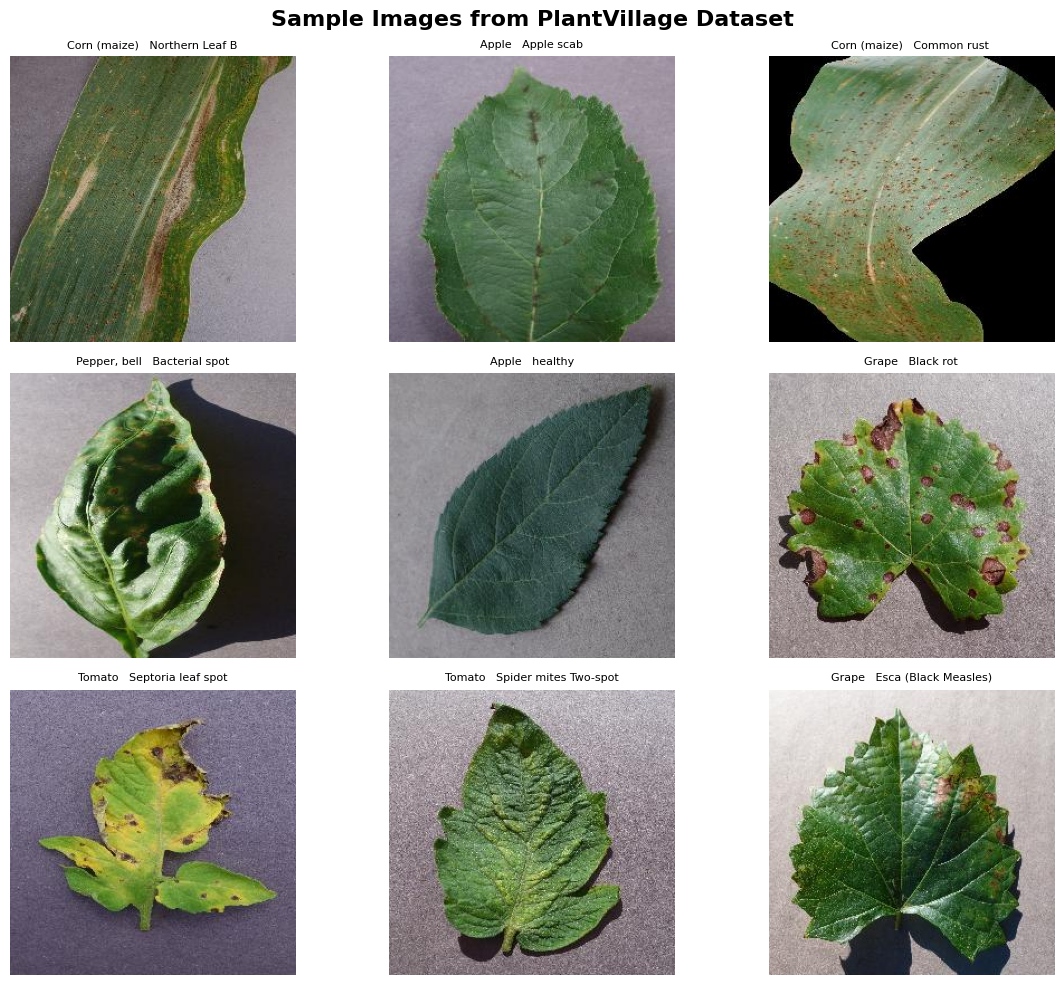

In [7]:
import matplotlib.image as mpimg

sample_classes = random.sample(os.listdir(DATA_DIR), 9)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Sample Images from PlantVillage Dataset', fontsize=16, fontweight='bold')

for ax, class_name in zip(axes.flatten(), sample_classes):
    class_path = os.path.join(DATA_DIR, class_name)
    img_file = random.choice(os.listdir(class_path))
    img = mpimg.imread(os.path.join(class_path, img_file))
    ax.imshow(img)
    ax.set_title(class_name.replace('_',' ')[:30], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## ⚙️ Step 4 — Data Preprocessing

| Step | What | Why |
|------|------|-----|
| Resize | 128×128 px | CNNs need fixed size |
| Normalize | 0–255 → 0–1 | Faster, stable training |
| Augmentation | Flip, rotate, zoom | Prevent overfitting |
| Split | 80% train / 20% val | Fair evaluation |

In [8]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_EPOCHS = 15
NUM_CLASSES = len(os.listdir(DATA_DIR))

print(f'Image size  : {IMG_SIZE}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Epochs      : {NUM_EPOCHS}')
print(f'Num classes : {NUM_CLASSES}')

# Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Validation data: only normalize, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

print('Data generators ready!')

Image size  : (128, 128)
Batch size  : 32
Epochs      : 15
Num classes : 38
Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Data generators ready!


## 🧠 Step 5 — Model 1: Custom CNN

Built from scratch. Uses Conv2D layers to detect patterns in images.

Architecture: 3 Conv blocks → GlobalAvgPooling → Dense → Output (38 classes)

In [9]:
def build_custom_cnn(num_classes):
    model = models.Sequential([
        layers.Input(shape=(128, 128, 3)),

        # Block 1: detect simple features (edges, colors)
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2: detect textures and spots
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3: detect disease patterns
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='Custom_CNN')
    return model


cnn_model = build_custom_cnn(NUM_CLASSES)
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,718 (1.27 MB)

 Trainable params: 330,758 (1.26 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Training Custom CNN...')
cnn_start = time.time()

cnn_history = cnn_model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

cnn_time = time.time() - cnn_start
print(f'CNN Training Time: {cnn_time/60:.1f} minutes')

Training Custom CNN...
Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 252s 174ms/step - accuracy: 0.6366 - loss: 1.2771 - val_accuracy: 0.3790 - val_loss: 3.7065 - learning_rate: 0.0010
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 230s 169ms/step - accuracy: 0.8136 - loss: 0.6037 - val_accuracy: 0.5919 - val_loss: 2.0097 - learning_rate: 0.0010
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 235s 173ms/step - accuracy: 0.8665 - loss: 0.4273 - val_accuracy: 0.8193 - val_loss: 0.6258 - learning_rate: 0.0010
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 236s 174ms/step - accuracy: 0.8935 - loss: 0.3369 - val_accuracy: 0.7006 - val_loss: 1.5122 - learning_rate: 0.0010
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 235s 173ms/step - accuracy: 0.9158 - loss: 0.2656 - val_accuracy: 0.7398 - val_loss: 1.0058 - learning_rate: 0.0010
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9191 - loss: 0.2524
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1358/1358 ━━━━━━━━━━━

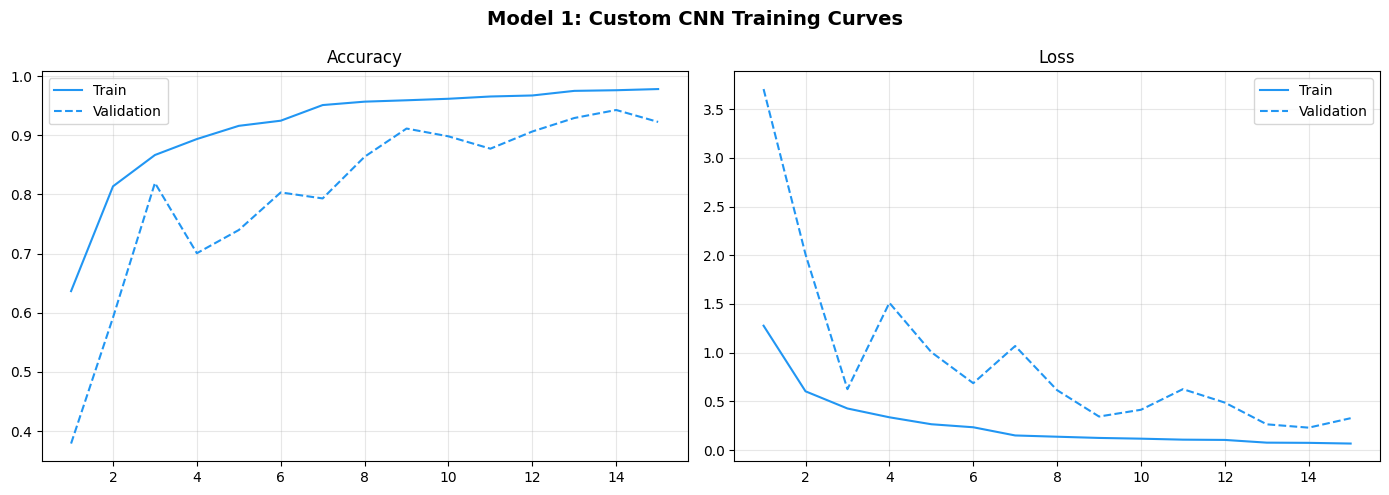

In [28]:
plot_history(cnn_history, 'Model 1: Custom CNN Training Curves', '#2196F3')

## 🔄 Step 6 — Model 2: CNN + LSTM

In [19]:
# ═══════════════════════════════════════════
# Model 2: CNN + LSTM for Image Classification
# ═══════════════════════════════════════════
# How it works:
# 1. CNN layers extract features from the image
# 2. Reshape features into a sequence
# 3. LSTM learns patterns across the sequence

def build_cnn_lstm(num_classes):
    model = models.Sequential([
        layers.Input(shape=(128, 128, 3)),

        # CNN part: extract features
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Reshape for LSTM: (batch, steps, features)
        layers.Reshape((32*32, 64)),

        # LSTM part: learn sequential patterns
        layers.LSTM(128, return_sequences=False),
        layers.Dropout(0.5),

        # Classifier
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_LSTM')
    return model


lstm_model = build_cnn_lstm(NUM_CLASSES)
lstm_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,006 (546.90 KB)

 Trainable params: 139,814 (546.15 KB)

 Non-trainable params: 192 (768.00 B)

In [20]:
print('Training CNN + LSTM...')
lstm_start = time.time()

lstm_history = lstm_model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

lstm_time = time.time() - lstm_start
print(f'CNN+LSTM Training Time: {lstm_time/60:.1f} minutes')

Training CNN + LSTM...
Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 268s 193ms/step - accuracy: 0.3096 - loss: 2.4593 - val_accuracy: 0.2691 - val_loss: 2.9147 - learning_rate: 0.0010
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 270s 199ms/step - accuracy: 0.4278 - loss: 1.9834 - val_accuracy: 0.1606 - val_loss: 3.4907 - learning_rate: 0.0010
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.4665 - loss: 1.8218
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 260s 192ms/step - accuracy: 0.4754 - loss: 1.7957 - val_accuracy: 0.1290 - val_loss: 4.3894 - learning_rate: 0.0010
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 258s 190ms/step - accuracy: 0.5407 - loss: 1.5418 - val_accuracy: 0.1966 - val_loss: 3.1995 - learning_rate: 5.0000e-04
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 268s 197ms/step - accuracy: 0.5599 - loss: 1.4632 - val_accuracy: 0.5469 - val_loss: 1.5088 - learning_rate: 5.0000e-04
Epoch 5: early stopping


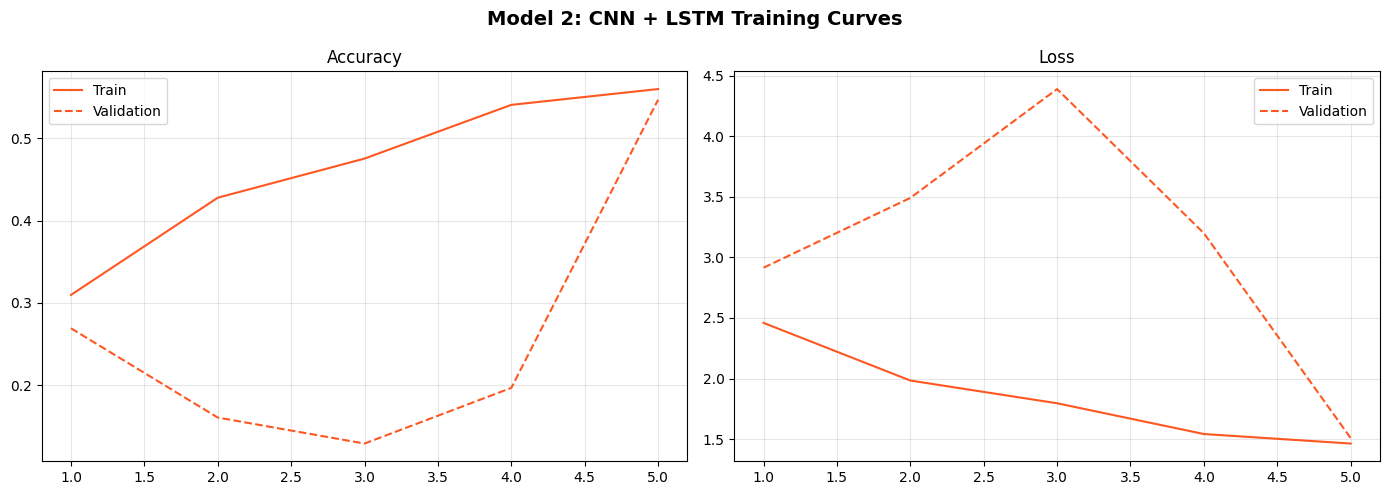

In [29]:
plot_history(lstm_history, 'Model 2: CNN + LSTM Training Curves', '#FF5722')

## 🚀 Step 7 — Model 3: Transfer Learning (MobileNetV2)

Uses a model pre-trained on 1.2M ImageNet images.
We freeze its weights and only train a new classification head.

**Phase 1:** Train new head only
**Phase 2:** Fine-tune top layers with small learning rate

In [11]:
base_model = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = layers.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = models.Model(inputs, outputs, name='Transfer_MobileNetV2')
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Transfer_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
print('Phase 1 — Training classification head...')
tl_start = time.time()

tl_history1 = tl_model.fit(
    train_generator, epochs=10,
    validation_data=val_generator,
    callbacks=callbacks, verbose=1
)
print('Phase 1 done!')

Phase 1 — Training classification head...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 253s 173ms/step - accuracy: 0.7625 - loss: 0.7948 - val_accuracy: 0.8680 - val_loss: 0.3902 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 216s 159ms/step - accuracy: 0.8487 - loss: 0.4669 - val_accuracy: 0.8940 - val_loss: 0.3096 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8631 - loss: 0.4196
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 216s 159ms/step - accuracy: 0.8657 - loss: 0.4123 - val_accuracy: 0.8898 - val_loss: 0.3256 - learning_rate: 0.0010
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 218s 160ms/step - accuracy: 0.8909 - loss: 0.3311 - val_accuracy: 0.9078 - val_loss: 0.2696 - learning_rate: 5.0000e-04
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 222s 163ms/step - accuracy: 0.8969 - loss: 0.3129 - val_accuracy: 0.9063 - val_loss: 0.2930 - learning_rate: 5.0000e-04
Epoch

In [13]:
print('Phase 2 — Fine-tuning top layers...')
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history2 = tl_model.fit(
    train_generator, epochs=10,
    validation_data=val_generator,
    callbacks=callbacks, verbose=1
)

tl_time = time.time() - tl_start
print(f'Transfer Learning Training Time: {tl_time/60:.1f} minutes')

Phase 2 — Fine-tuning top layers...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 244s 168ms/step - accuracy: 0.7484 - loss: 0.8783 - val_accuracy: 0.8977 - val_loss: 0.3104 - learning_rate: 1.0000e-05
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 219s 161ms/step - accuracy: 0.8502 - loss: 0.4780 - val_accuracy: 0.9096 - val_loss: 0.2745 - learning_rate: 1.0000e-05
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8697 - loss: 0.4041
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 218s 161ms/step - accuracy: 0.8749 - loss: 0.3894 - val_accuracy: 0.9185 - val_loss: 0.2446 - learning_rate: 1.0000e-05
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 218s 161ms/step - accuracy: 0.8912 - loss: 0.3428 - val_accuracy: 0.9237 - val_loss: 0.2296 - learning_rate: 5.0000e-06
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 218s 161ms/step - accuracy: 0.8951 - loss: 0.3240 - val_accuracy: 0.9263 - val_loss: 0.2202 - learning_rate: 5.0000e-06

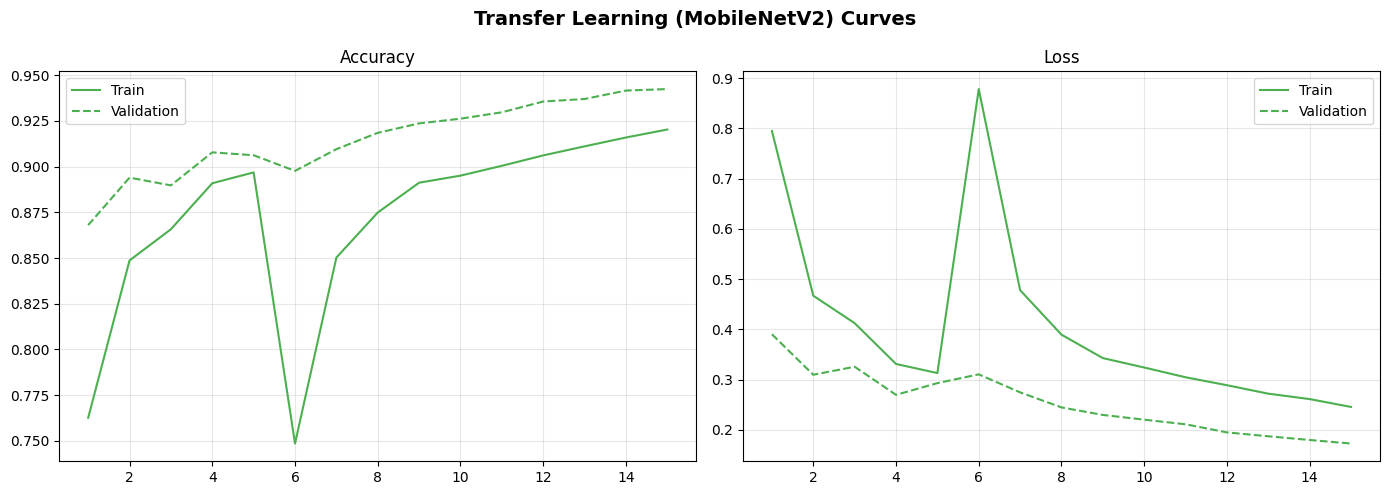

In [30]:
combined_tl = copy.deepcopy(tl_history1)
for key in combined_tl.history:
    if key in tl_history2.history:
        combined_tl.history[key] += tl_history2.history[key]

plot_history(combined_tl, 'Transfer Learning (MobileNetV2) Curves', '#4CAF50')

## 📊 Step 8 — Results & Comparison

Custom CNN       : 94.26%  loss=0.2306  time=59.1min
CNN + LSTM       : 26.91%  loss=2.9147  time=22.1min
Transfer Learning: 94.25%  loss=0.1726  time=57.8min


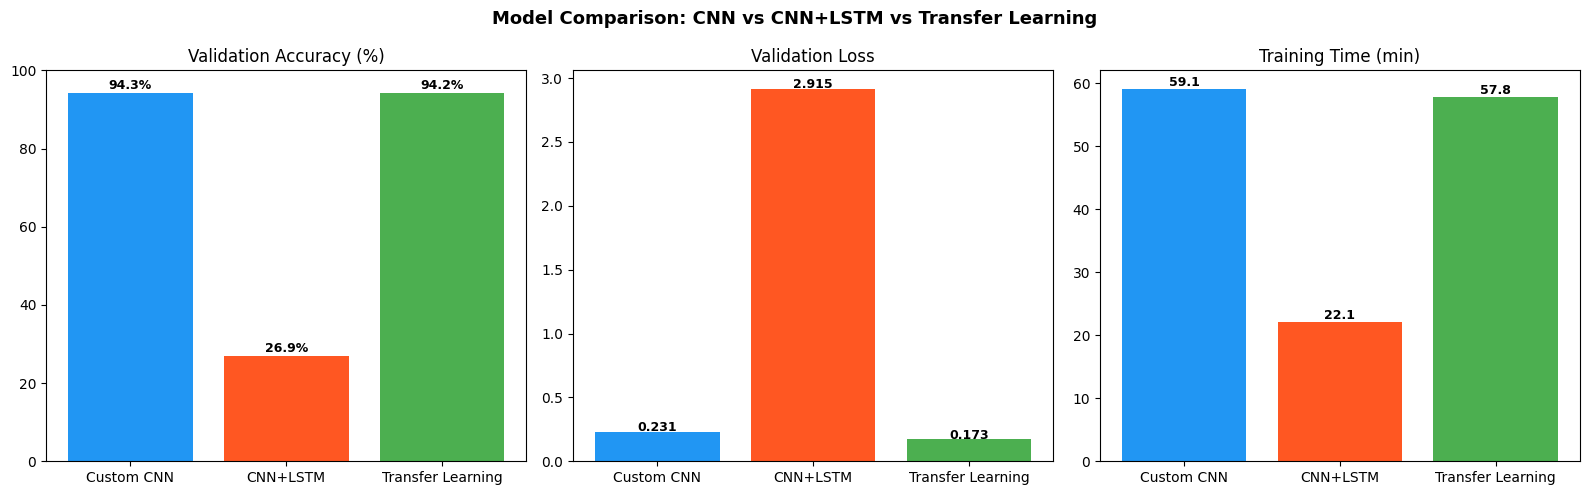

In [25]:
# Evaluate all 3 models
val_generator.reset()
cnn_loss, cnn_acc = cnn_model.evaluate(val_generator, verbose=0)
val_generator.reset()
lstm_loss, lstm_acc = lstm_model.evaluate(val_generator, verbose=0)
val_generator.reset()
tl_loss, tl_acc = tl_model.evaluate(val_generator, verbose=0)

print(f'Custom CNN       : {cnn_acc*100:.2f}%  loss={cnn_loss:.4f}  time={cnn_time/60:.1f}min')
print(f'CNN + LSTM       : {lstm_acc*100:.2f}%  loss={lstm_loss:.4f}  time={lstm_time/60:.1f}min')
print(f'Transfer Learning: {tl_acc*100:.2f}%  loss={tl_loss:.4f}  time={tl_time/60:.1f}min')

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison: CNN vs CNN+LSTM vs Transfer Learning',
             fontsize=13, fontweight='bold')
names = ['Custom CNN', 'CNN+LSTM', 'Transfer Learning']
colors = ['#2196F3', '#FF5722', '#4CAF50']

axes[0].bar(names, [cnn_acc*100, lstm_acc*100, tl_acc*100], color=colors)
axes[0].set_title('Validation Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate([cnn_acc*100, lstm_acc*100, tl_acc*100]):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(names, [cnn_loss, lstm_loss, tl_loss], color=colors)
axes[1].set_title('Validation Loss')
for i, v in enumerate([cnn_loss, lstm_loss, tl_loss]):
    axes[1].text(i, v+0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

axes[2].bar(names, [cnn_time/60, lstm_time/60, tl_time/60], color=colors)
axes[2].set_title('Training Time (min)')
for i, v in enumerate([cnn_time/60, lstm_time/60, tl_time/60]):
    axes[2].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 📝 Step 9 — Final Summary

In [31]:
print('='*55)
print('   PLANT DISEASE DETECTION — FINAL SUMMARY')
print('='*55)
print(f'Dataset       : PlantVillage ({NUM_CLASSES} classes)')
print(f'Image size    : {IMG_SIZE[0]}x{IMG_SIZE[1]} px')
print(f'Augmentation  : rotation, flip, zoom, shift')
print()
print(f'Custom CNN       : {cnn_acc*100:.2f}% | {cnn_time/60:.1f} min')
print(f'CNN + LSTM       : {lstm_acc*100:.2f}% | {lstm_time/60:.1f} min')
print(f'Transfer Learning: {tl_acc*100:.2f}% | {tl_time/60:.1f} min')
print()
accs = {'Custom CNN': cnn_acc, 'CNN+LSTM': lstm_acc, 'Transfer Learning': tl_acc}
winner = max(accs, key=accs.get)
print(f'Best Model    : {winner} ({accs[winner]*100:.2f}%)')
print('='*55)

   PLANT DISEASE DETECTION — FINAL SUMMARY
Dataset       : PlantVillage (38 classes)
Image size    : 128x128 px
Augmentation  : rotation, flip, zoom, shift

Custom CNN       : 94.26% | 59.1 min
CNN + LSTM       : 26.91% | 22.1 min
Transfer Learning: 94.25% | 57.8 min

Best Model    : Custom CNN (94.26%)
